In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [3]:
symbol_lst = ["C", "CS", "RR", "JD", "LH", "AP", "CJ", "SR", "CF", "CY"]

In [4]:
init_money_lst = []
for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  首个交易日: {first_date}")
    print(f"  95分位数价格: {info['price_95th']:.2f}")
    print(f"  合约乘数: {info['contract_multiplier']}")
    print(f"  保证金率: {info['margin_rate']:.2%}")
    print(f"  10手保证金: {margin:,.2f} 元")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} 元")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    print(f"  分均成交额: {activity['avg_turnover']:,.0f} 元")
    init_money_lst.append(int(margin / 0.4))


品种: C (玉米)
  首个交易日: 2021-02-02
  95分位数价格: 2381.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 16,667.00 元
  40%保证金所需本金: 41,668 元
  分均持仓量: 1,017,181
  分均成交量: 1,483
  分均成交额: 33,631,985 元

品种: CS (玉米淀粉)
  首个交易日: 2021-02-02
  95分位数价格: 2729.00
  合约乘数: 10
  保证金率: 6.00%
  10手保证金: 16,374.00 元
  40%保证金所需本金: 40,935 元
  分均持仓量: 192,842
  分均成交量: 319
  分均成交额: 8,245,518 元

品种: RR (梗米)
  首个交易日: 2021-02-02
  95分位数价格: 3634.00
  合约乘数: 10
  保证金率: 6.00%
  10手保证金: 21,804.00 元
  40%保证金所需本金: 54,510 元
  分均持仓量: 9,704
  分均成交量: 5
  分均成交额: 194,933 元

品种: JD (鸡蛋)
  首个交易日: 2021-02-02
  95分位数价格: 3594.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 12,579.00 元
  40%保证金所需本金: 31,448 元
  分均持仓量: 229,503
  分均成交量: 970
  分均成交额: 30,471,621 元

品种: LH (生猪)
  首个交易日: 2021-02-02
  95分位数价格: 14360.00
  合约乘数: 16
  保证金率: 8.00%
  10手保证金: 183,808.00 元
  40%保证金所需本金: 459,520 元
  分均持仓量: 100,787
  分均成交量: 224
  分均成交额: 45,026,255 元

品种: AP (苹果)
  首个交易日: 2021-02-01
  95分位数价格: 9731.00
  合约乘数: 10
  保证金率: 15.00%
  10手保证金: 145,965.00 元
  40%保证金所需本金: 364,912 元
  分均持仓

In [5]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'C': 41667,
 'CS': 40934,
 'RR': 54510,
 'JD': 31447,
 'LH': 459520,
 'AP': 364912,
 'CJ': 142687,
 'SR': 90945,
 'CF': 130243,
 'CY': 130312}

In [6]:
weights = dict(zip(symbol_lst, [2_000_000 // x for x in init_money_lst]))
weights

{'C': 47,
 'CS': 48,
 'RR': 36,
 'JD': 63,
 'LH': 4,
 'AP': 5,
 'CJ': 14,
 'SR': 21,
 'CF': 15,
 'CY': 15}

In [7]:
train_label = 5
rtn_mul = 1

bt_params = (0.9, 0.5, 10, 5*345)
train_end_date = '2025-01-01'

In [8]:
def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    bt.load_factor(symbol, end_date=bt.window_end)
    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [9]:
merged_data_lst = Parallel(n_jobs=len(symbol_lst))(delayed(run_res)(symbol, bt_params)
                                                   for symbol in symbol_lst)

trading_hours ['09:00-11:30', '13:30-15:00']


  3%|▎         | 1385/49723 [00:02<01:38, 493.18it/s]

trading_hours ['09:00-11:30', '13:30-15:00']


 10%|█         | 4997/49723 [00:13<02:17, 326.05it/s]

trading_hours ['09:00-11:30', '13:30-15:00']


...

  7%|▋         | 6231/85767 [00:18<03:40, 360.06it/s]]

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


 90%|████████▉ | 52732/58772 [02:13<00:12, 492.46it/s]

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


100%|██████████| 90527/90527 [02:51<00:00, 527.51it/s]


In [10]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        df = df.iloc[:-30]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill()

In [11]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights)
merged_df_all

,C,CS,RR,JD,LH,AP,CJ,SR,CF,CY
date,,,,,,,,,,
2025-01-02,2.007894e+06,1.983248e+06,1.975386e+06,2.044126e+06,1.889227e+06,1.841335e+06,1.968059e+06,1.858812e+06,1.967552e+06,1.988680e+06
2025-01-03,2.025041e+06,2.043409e+06,1.986683e+06,2.104161e+06,1.935581e+06,1.821563e+06,1.968694e+06,1.796335e+06,1.999913e+06,2.032657e+06
2025-01-06,2.077836e+06,2.044721e+06,2.009567e+06,2.098887e+06,1.933045e+06,1.874540e+06,2.017236e+06,1.780112e+06,1.989576e+06,2.083605e+06
2025-01-07,2.174450e+06,2.041134e+06,2.073372e+06,2.115474e+06,1.989472e+06,1.868786e+06,2.023118e+06,1.758419e+06,2.001035e+06,2.082753e+06
2025-01-08,2.169994e+06,2.107199e+06,2.177341e+06,2.107897e+06,1.954166e+06,1.851914e+06,2.017655e+06,1.781710e+06,2.039147e+06,2.075876e+06
...,...,...,...,...,...,...,...,...,...,...
2026-01-05,6.466462e+06,4.005444e+06,6.106986e+06,3.930035e+06,4.907799e+06,1.798035e+06,2.396286e+06,2.782832e+06,4.197626e+06,4.642285e+06
2026-01-06,6.466462e+06,4.005444e+06,6.106986e+06,3.955130e+06,4.907799e+06,1.798035e+06,2.396286e+06,2.782832e+06,4.197626e+06,4.642285e+06
2026-01-07,6.466462e+06,4.005444e+06,6.106986e+06,3.993573e+06,4.907799e+06,1.798035e+06,2.396286e+06,2.782832e+06,4.197626e+06,4.642285e+06


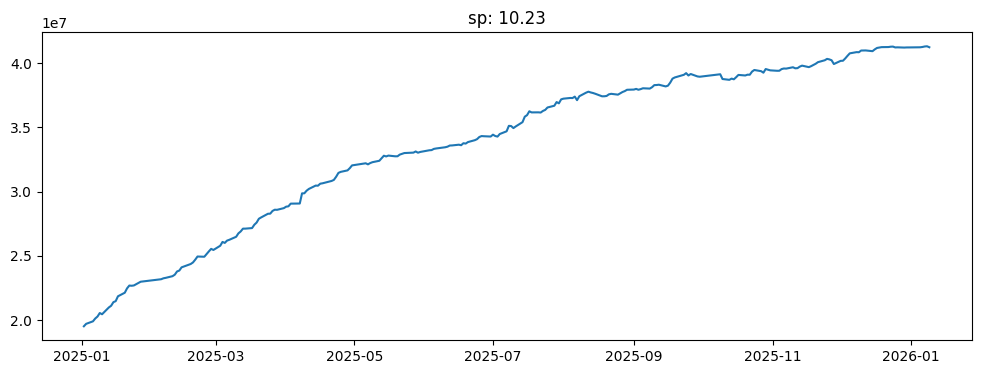

In [12]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

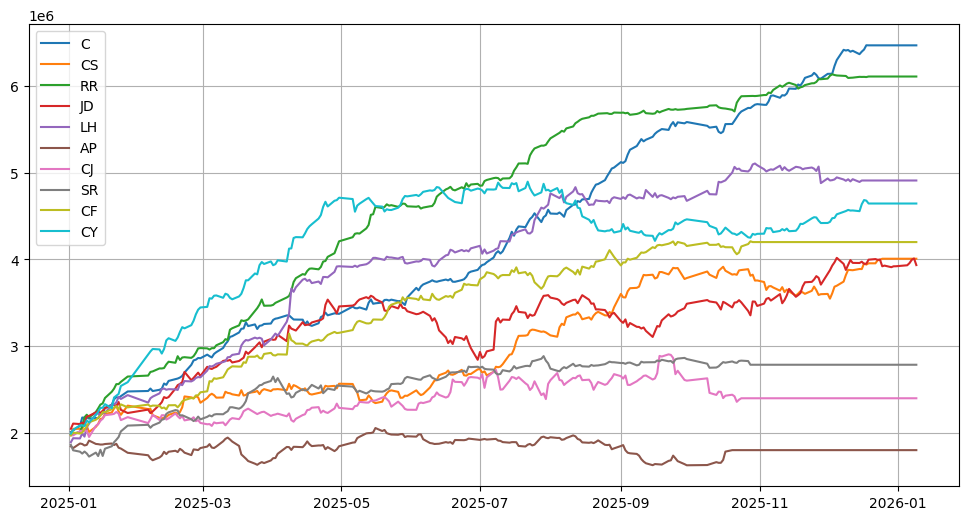

In [13]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [14]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res

,C,CS,RR,JD,LH,AP,CJ,SR,CF,CY
多头(+1) 数量,19203,20874,17884,11868,12024,10310,9884,17473,16929,19613
空头(-1) 数量,18311,16702,17523,13163,12687,10389,10833,14201,16579,17939
空仓(0) 数量,53015,54333,50362,37343,34063,29026,29908,45911,44422,52429
多头占比,21.21%,22.71%,20.85%,19.03%,20.46%,20.73%,19.52%,22.52%,21.72%,21.80%
空头占比,20.23%,18.17%,20.43%,21.10%,21.59%,20.89%,21.40%,18.30%,21.27%,19.94%
空仓占比,58.56%,59.12%,58.72%,59.87%,57.96%,58.37%,59.08%,59.18%,57.00%,58.27%
交易日数量,266,270,266,278,262,221,225,228,229,266
总收益(非年化%),274.07,140.98,229.91,137.62,177.52,14.81,4.98,46.73,127.09,169.37
总交易次数（开平算一次）,4547,5457,3412,3198,2616,1558,2171,3317,3347,3106
日均交易次数（开平算一次）,17.09,20.21,12.83,11.50,9.98,7.05,9.65,14.55,14.62,11.68
